In [1]:
import os
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt


hourly_data = '../DATA/rainfall/hourly_gauges_SIATA_EPM/'

hourly_files = sorted(glob(hourly_data + 'H_Datos_Procesados_Est_*.csv'))

stations_with_paths = [
    (int(os.path.basename(file).split('_')[-1].split('.')[0]), file) 
    for file in hourly_files]

stations_with_paths_sorted = sorted(stations_with_paths, key=lambda x: x[0])

# Filtra las estaciones de SIATA excluyendo las estaciones de EPM (últimas 16)
siata_stations_with_paths = stations_with_paths_sorted[:]


siata_hourly_files = [station[1] for station in siata_stations_with_paths]

#Cargar y Renombrar Datos de las Estaciones
data_frames = []
station_numbers = []

for station_number, file in siata_stations_with_paths:
    station_data = pd.read_csv(file, index_col='Fecha', parse_dates=True)
    
    # Verifica y elimina la columna 'Unnamed: 0' si existe
    if 'Unnamed: 0' in station_data.columns:
        station_data = station_data.drop(columns=['Unnamed: 0'])
    
    if 'P' in station_data.columns:
        station_data.rename(columns={'P': f'Est_{station_number}'}, inplace=True)
    else:
        precip_column = [col for col in station_data.columns if 'P' in col.upper()]
        if precip_column:
            station_data.rename(columns={precip_column[0]: f'Est_{station_number}'}, inplace=True)
        else:
            print(f"Advertencia: No se encontró columna de precipitación en {file}")
            continue
    
    data_frames.append(station_data)
    station_numbers.append(station_number)

all_stations_df = pd.concat(data_frames, axis=1, join='outer')

rainfall_df = all_stations_df[all_stations_df.index >= '1970-01-01']

rainfall_df['Fecha'] = pd.to_datetime(rainfall_df.index)

/tmp/ipykernel_3396139/3948107517.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rainfall_df['Fecha'] = pd.to_datetime(rainfall_df.index)
/tmp/ipykernel_3396139/3948107517.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rainfall_df['Fecha'] = pd.to_datetime(rainfall_df.index)


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hourly_dir = Path("../DATA/rainfall/hourly_gauges_SIATA_EPM")

files = sorted(hourly_dir.glob("H_Datos_Procesados_Est_*.csv"))

frames = []
for f in files:
    est = int(f.stem.split("_")[-1])             # Nº de estación
    df = (pd.read_csv(f, parse_dates=['Fecha'], index_col='Fecha')
            .rename(columns={'P': 'rain_mm'})    # Igualamos nombre de la columna
            .drop(columns=lambda c: c.startswith('Unnamed'), errors='ignore')
            .assign(station=est))
    frames.append(df[['station', 'rain_mm']])    # Mantén solo lo necesario

rain_long = pd.concat(frames)                    # (Fecha-hora, estación, lluvia)
rain_long = rain_long.loc['1970':]               # Recorte temporal

# ---------- 2. ONI y clasificación ENSO ----------
oni = (pd.read_excel("../DATA/rainfall/ENSO/ONI.xlsx")
         .melt(id_vars='Year', var_name='Period', value_name='ONI'))

map_period = {'DJF':1,'JFM':2,'FMA':3,'MAM':4,'AMJ':5,'MJJ':6,
              'JJA':7,'JAS':8,'ASO':9,'SON':10,'OND':11,'NDJ':12}
oni['Month'] = oni['Period'].map(map_period)

oni['ENSO'] = np.select(
    [oni['ONI'] >= 0.5, oni['ONI'] <= -0.5],
    ['El Niño', 'La Niña'],
    default='Neutral'
)

# ---------- 3. Agregar lluvia diaria y unir con ENSO ----------
rain_long['Date']  = rain_long.index.date
rain_long['Year']  = rain_long.index.year
rain_long['Month'] = rain_long.index.month

# Suma/medio diaria por estación (usa .mean() si prefieres intensidad media)
daily = (rain_long
         .groupby(['Date', 'station'])['rain_mm']
         .sum()
         .reset_index())

# Media diaria entre estaciones disponibles (sin NaN)
daily_avg = (daily
             .groupby('Date')['rain_mm']
             .mean()
             .rename('avg_rain_mm')
             .reset_index())

# Añadimos ENSO
daily_avg['Year']  = pd.to_datetime(daily_avg['Date']).dt.year
daily_avg['Month'] = pd.to_datetime(daily_avg['Date']).dt.month

daily_avg = daily_avg.merge(
    oni[['Year', 'Month', 'ENSO']],
    on=['Year', 'Month'],
    how='left'
)

# ---------- 4. Promedio final por fase ENSO ----------
ensoplot = (daily_avg
            .groupby('ENSO')['avg_rain_mm']
            .mean()
            .sort_values())

print(ensoplot)

ENSO
El Niño    4.189566
Neutral    5.093775
La Niña    5.673769
Name: avg_rain_mm, dtype: float64


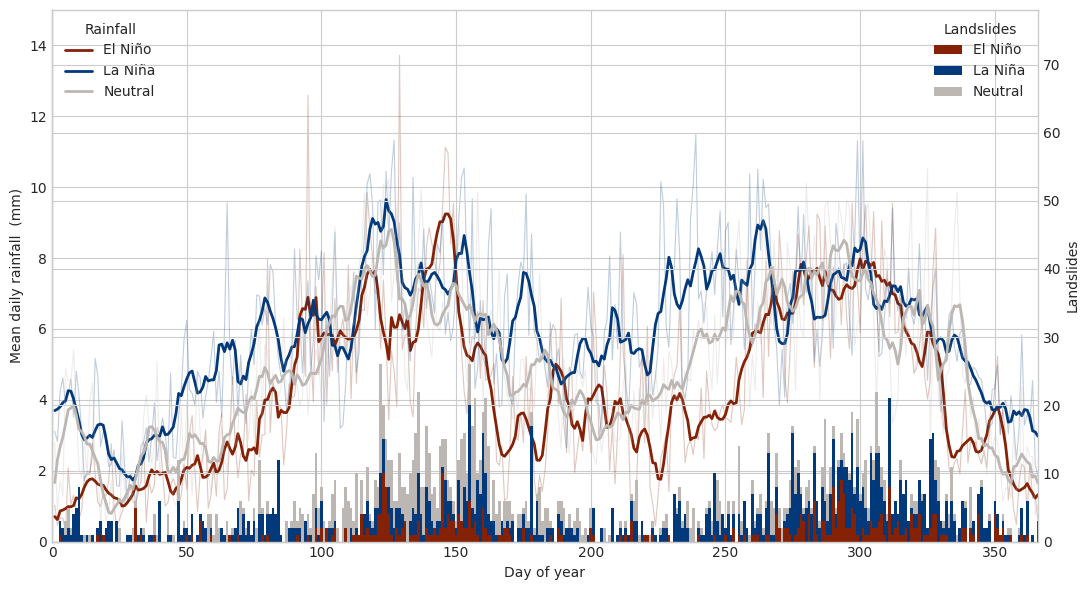

In [4]:

daily_avg['DayOfYear'] = pd.to_datetime(daily_avg['Date']).dt.dayofyear

rain_enso = (daily_avg
             .groupby(['DayOfYear', 'ENSO'])['avg_rain_mm']
             .mean()
             .reset_index())

# ---------- 2. Inventario de deslizamientos ----------

# Load the landslide inventory CSV file to inspect its structure and find relevant date columns
landslide_file_path = '../DATA/landslides/inventory_GEOHAZARDS_20240824.csv'

# Load the landslide data
landslide_df = pd.read_csv(landslide_file_path)

# Convert the 'Fecha' column to datetime format
landslide_df['Fecha'] = pd.to_datetime(landslide_df['Fecha'], errors='coerce')

# Remove rows with invalid dates
landslide_df = landslide_df.dropna(subset=['Fecha'])

# Extract the day of the year from 'Fecha'
landslide_df['DayOfYear'] = landslide_df['Fecha'].dt.dayofyear

# Count the number of landslides for each day of the year
landslide_count_by_day = landslide_df.groupby('DayOfYear').size().reset_index(name='LandslideCount')

# --- asigna fase ENSO a cada deslizamiento ---
landslide_df['Year']  = landslide_df['Fecha'].dt.year
landslide_df['Month'] = landslide_df['Fecha'].dt.month

oni_file_path = '../DATA/rainfall/ENSO/ONI.xlsx'
oni_df = pd.read_excel(oni_file_path)

# Reshape ONI data (the reshaping step you saw earlier)
oni_melted = oni_df.melt(id_vars=['Year'], var_name='Period', value_name='ONI')

month_from_period = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4, 'AMJ': 5, 'MJJ': 6,
    'JJA': 7, 'JAS': 8, 'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
}
oni_melted['Month'] = oni_melted['Period'].map(month_from_period)

def classify_oni(oni_value):
    if oni_value >= 0.5:
        return 'El Niño'
    elif oni_value <= -0.5:
        return 'La Niña'
    else:
        return 'Neutral'

oni_melted['ONI_Category'] = oni_melted['ONI'].apply(classify_oni)

ls_enso = (landslide_df
           .merge(oni_melted[['Year', 'Month', 'ONI_Category']],
                  on=['Year', 'Month'], how='left')
           .dropna(subset=['ONI_Category']))

# --- cuenta por día-año y fase ENSO ---
ls_enso['DayOfYear'] = ls_enso['Fecha'].dt.dayofyear
ls_counts = (ls_enso
             .groupby(['DayOfYear', 'ONI_Category'])
             .size()
             .unstack(fill_value=0)            # columnas: El Niño | La Niña | Neutral
             .reindex(range(1, 367), fill_value=0))

# --- colores coherentes con las líneas ---
import cmcrameri.cm as cm
# Colores coherentes con el heat-map
# color_nina   = '#3b4cc0'
# color_neutro = '#dddcdc'
# color_nino   = '#b40426'
color_nina   = cm.vik(0.1)   # azul
color_neutro = cm.vik(0.5)   # neutro
color_neutro =  tuple(np.array(color_neutro[:3]) * 0.8) + (color_neutro[3],)
color_nino   = cm.vik(0.9)   # rojo
stack_cols = ['El Niño', 'La Niña', 'Neutral']
stack_colors = [color_nino, color_nina, color_neutro]


# ---------- 3. Figura combinada ----------
colors = {'La Niña': color_nina, 'El Niño': color_nino, 'Neutral': color_neutro}

fig, ax1 = plt.subplots(figsize=(11, 6))

# 3a) lluvia (líneas finas + suavizado 7-días más grueso)
for ens in rain_enso['ENSO'].unique():
    sub = rain_enso[rain_enso['ENSO'] == ens].set_index('DayOfYear').sort_index()
    ax1.plot(sub.index, sub['avg_rain_mm'],
             color=colors[ens], alpha=0.25, linewidth=0.8)
    ax1.plot(sub.index,
             sub['avg_rain_mm'].rolling(7, center=True, min_periods=1).mean(),
             color=colors[ens], linewidth=2,
             label=f"{ens}")

ax1.set_ylabel("Mean daily rainfall  (mm)")
ax1.set_xlim(0, 366)
ax1.set_ylim(0, 15)  # Ajusta el límite superior según tus datos
ax1.set_xlabel("Day of year")

# 3b) deslizamientos (barras negras en eje secundario)
ax2 = ax1.twinx()

bottom = None
for col, c in zip(stack_cols, stack_colors):
    ax2.bar(ls_counts.index, ls_counts[col],
            width=1, bottom=bottom, color=c, label=col)
    bottom = (ls_counts[col] if bottom is None else bottom + ls_counts[col])

# ax2.bar(landslide_count_by_day['DayOfYear'], landslide_count_by_day['LandslideCount'], 
#         color='black', label='Landslides', width=1)

ax2.set_ylabel('Landslides')
ax2.set_ylim(0, landslide_count_by_day['LandslideCount'].max() * 3)  # Add some margin to the limit


# ---------- 4. Estética ----------
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
ax1.legend(loc="upper left", title="Rainfall")
ax2.legend(loc="upper right", title="Landslides")

plt.tight_layout()
#plt.savefig("../../FIGURES/fig04.png", dpi=300, bbox_inches="tight")
plt.show()

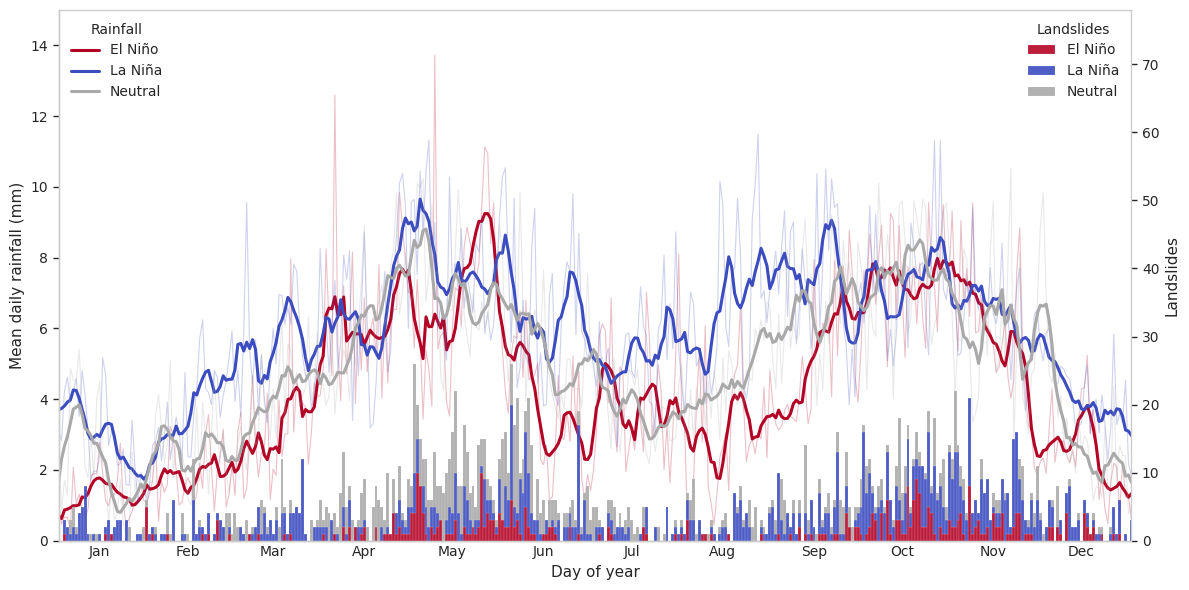

In [5]:
plt.style.use('seaborn-v0_8-whitegrid')          # fondo limpio con grilla tenue

stack_cols   = ['El Niño', 'La Niña', 'Neutral']
stack_colors = ['#b40426', '#3b4cc0', 'darkgray']
line_colors  = {'La Niña': '#3b4cc0', 'El Niño': '#b40426', 'Neutral': 'darkgray'}

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- lluvia (líneas finas + media móvil 7-d) ---
for ens in rain_enso['ENSO'].unique():
    sub = rain_enso[rain_enso['ENSO'] == ens].set_index('DayOfYear').sort_index()
    ax1.plot(sub.index, sub['avg_rain_mm'], color=line_colors[ens],
             alpha=0.25, lw=0.8)
    ax1.plot(sub.index,
             sub['avg_rain_mm'].rolling(7, center=True, min_periods=1).mean(),
             color=line_colors[ens], lw=2.2, label=ens)

ax1.set_ylabel('Mean daily rainfall (mm)', fontsize=11)
ax1.set_xlim(1, 366)
ax1.set_ylim(0, 15)
ax1.set_xlabel('Day of year', fontsize=11)
ax1.grid(False)    # grilla suave solo horizontal

# ticks con meses aproximados
month_ticks  = np.arange(1, 337, 30)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
day_of_year_mid = [15, 45, 74, 105, 135, 166,
                   196, 227, 258, 288, 319, 349]   # 12 valores
ax1.set_xticks(day_of_year_mid)
ax1.set_xticklabels(month_labels, fontsize=10)
ax1.tick_params(axis='y',                 # solo vertical
                which='major',            # ticks principales
                length=4, width=1.0,      # largo y grosor
                direction='out')          # 'in', 'out' o 'inout'

# --- deslizamientos apilados ---
ax2 = ax1.twinx()
bottom = np.zeros_like(ls_counts.index, dtype=int)
for col, c in zip(stack_cols, stack_colors):
    ax2.bar(ls_counts.index, ls_counts[col], width=1,
            bottom=bottom, color=c, edgecolor='white', linewidth=0.1, alpha=0.9,
            label=col)
    bottom += ls_counts[col]

ax2.set_ylabel('Landslides', fontsize=11)
ax2.set_ylim(0, landslide_count_by_day['LandslideCount'].max()*3)
ax2.tick_params(axis='y',
                which='major',
                length=4, width=1.0,
                direction='out')

# --- leyendas sin marco ---
ax1.legend(title='Rainfall', frameon=False, loc='upper left')
ax2.legend(title='Landslides',    frameon=False, loc='upper right')

for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax2.grid(False)  
plt.tight_layout()
plt.savefig('../FIGURES/fig04.png', dpi=500, bbox_inches='tight')
plt.show()